# Создание моделей для предсказания свойств углепластика, полученного по автоклавной технологии технологии

In [1]:
import pandas as pd
import numpy as np


# инструменты для построения модели:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression # инструмент для создания и обучения модели
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели
from sklearn import metrics # инструменты для оценки точности модели
from xgboost import XGBRegressor

import matplotlib as plt

import pickle

RANDOM_SEED = 42

In [2]:
df = pd.read_csv('data/dataset_prepaired.csv')
df.head()

,Linera density,Density yarn,Strength Gpa,Module Gpa,lengthening,Mass size,breaking the loop,Surface density of the fabric,Prepreg surface density,Resin content,viscosity,Gelation time,Resin Tg,technology,Thickness of the monolayer,density,Strength_plastik,Module_plastik,LSS,Plastik_Tg
0,188.0,1.758,4.59,253.0,1.814229,1.0,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
1,189.0,1.758,4.48,260.0,1.723077,1.1,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
2,188.0,1.759,4.28,257.0,1.665370,1.0,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
3,187.0,1.758,4.77,256.0,1.863281,1.0,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
4,190.0,1.757,4.56,255.0,1.788235,0.9,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0


In [3]:

df = df[df['technology'] == 1]
df = df.drop('technology', axis=1)

In [4]:
df = df.rename(columns={'Thickness of the monolayer' : 'Thickness_monolayer',
                        'Module_plastik ' : 'Module_plastik'})

In [50]:
x1 = np.array([[185,62, 1.769, 4.56, 261, 1.75, 1.07, 26.8, 200, 325.7, 38.57, 32.35, 12, 153]])

### Модель для предсказания толщины монослоя Thickness_monolayer

In [6]:
train_data_thickness = df.drop(['density', 'Strength_plastik', 'Module_plastik',
       'LSS', 'Plastik_Tg', 'Strength Gpa', 'Module Gpa', 'lengthening', 'Linera density'], axis=1)

X = train_data_thickness.drop(['Thickness_monolayer'], axis=1)
y = train_data_thickness.Thickness_monolayer.values

In [7]:
# воспользуемся специальной функцие train_test_split для разделения тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED)

In [8]:
# НАСТРОЙКИ 
model_rf_thikness = RandomForestRegressor(
    n_estimators=500,
    max_features=4,
    min_samples_leaf=5,
    max_depth=9,
    verbose=1, 
    n_jobs=-1,
    random_state=RANDOM_SEED)

In [9]:
# обучаем модель на тестовом наборе данных
model_rf_thikness.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_rf_thikness.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.1s finished


In [51]:
model_rf_thikness.predict(x1)

/home/alexandr/anaconda3/envs/ptn312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


ValueError: X has 14 features, but RandomForestRegressor is expecting 9 features as input.

<Axes: >

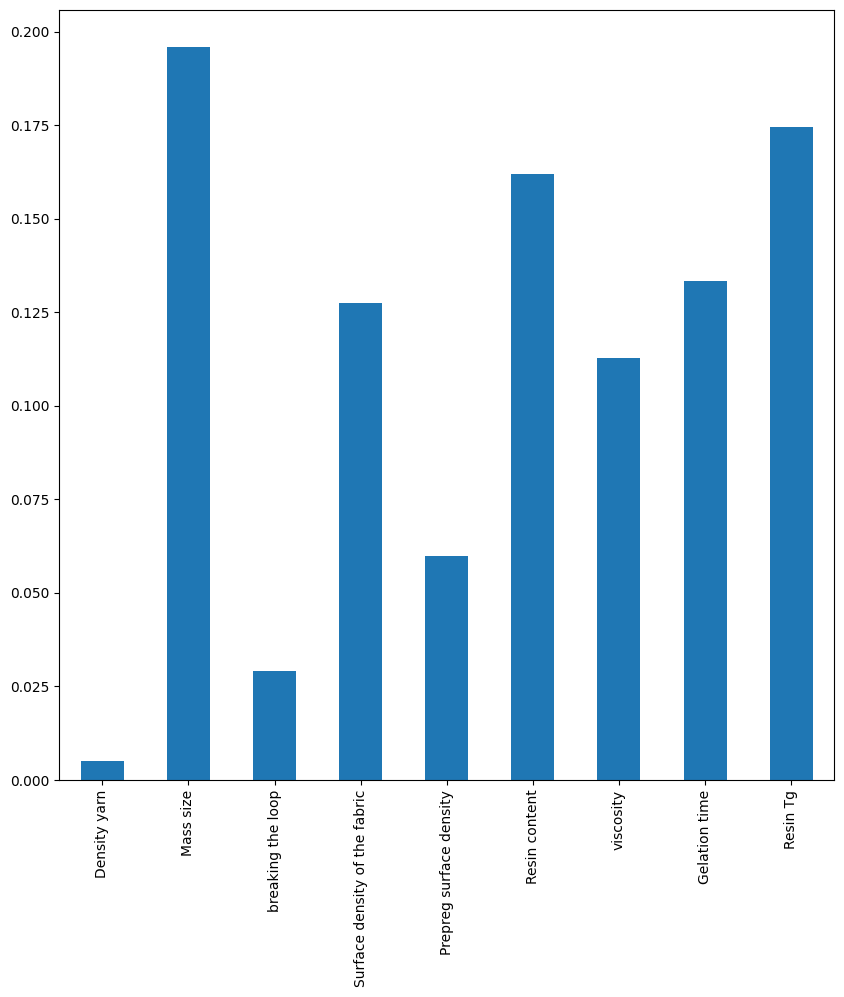

In [10]:
plt.rcParams['figure.figsize'] = (10,10)

feat_imp = pd.Series(model_rf_thikness.feature_importances_, X.columns)

feat_imp.plot(kind='bar')

In [11]:
def mean_absolute_percentage_error(y_tr, y_pr):
    """Получение средней абсолютной ошибки"""
    y_tr, y_pr = np.array(y_tr), np.array(y_pr)
    return np.mean(np.abs((y_tr - y_pr) / y_tr)) * 100

In [12]:
# сравниваем предсказанные значения (y_pred) с реальными (y_test), 
# метрика mean squared error, MSE показывает среднеквадратичное отклонение:

def mean_squared_error(y_tr, y_pr):
    """Получение средней абсолютной ошибки"""
    y_tr, y_pr = np.array(y_tr), np.array(y_pr)
    return np.mean(np.abs((y_tr - y_pr)**2)) 

In [13]:
print('model_rf_thikness MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_rf_thiknessMAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_rf_thikness MSE: 0.0
model_rf_thiknessMAPE: 0.026


In [14]:
model_lr_thikness = LinearRegression()

# обучаем модель на тестовом наборе данных
model_lr_thikness.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_lr_thikness.predict(X_test)

print('model_lr_thiknessMSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_lr_thikness MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_lr_thiknessMSE: 0.0
model_lr_thikness MAPE: 1.38


In [15]:
print('Линейная регрессия. Толщина монослоя:', np.average(model_lr_thikness.predict(X)))
print('Случайный лес регрессия. Толщина монослоя:', np.average(model_rf_thikness.predict(X)))

Линейная регрессия. Толщина монослоя: 0.20892818553468223
Случайный лес регрессия. Толщина монослоя: 0.20895939101949668


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.0s finished


### Модель для предсказания плотности углепластика density

In [16]:
train_data_density = df.drop(['Thickness_monolayer', 'Strength_plastik', 'Module_plastik',
                            'LSS', 'Plastik_Tg'], axis=1)

X = train_data_density.drop(['density'], axis=1)
y = train_data_density.density.values

In [17]:
# воспользуемся специальной функцие train_test_split для разделения тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED)

# НАСТРОЙКИ 
model_rf_density = RandomForestRegressor(
    n_estimators=500,
    max_features=4,
    min_samples_leaf=5,
    max_depth=9,
    verbose=1, 
    n_jobs=-1, 
    random_state=RANDOM_SEED)

# обучаем модель на тестовом наборе данных
model_rf_density.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_rf_density.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.0s finished


In [18]:
print('model_rf_density MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_rf_density MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_rf_density MSE: 0.0
model_rf_density MAPE: 0.004


In [19]:
model_lr_density = LinearRegression()

# обучаем модель на тестовом наборе данных
model_lr_density.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_lr_density.predict(X_test)

print('model_lr_density MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_lr_density MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_lr_density MSE: 0.0
model_lr_density MAPE: 0.404


<Axes: >

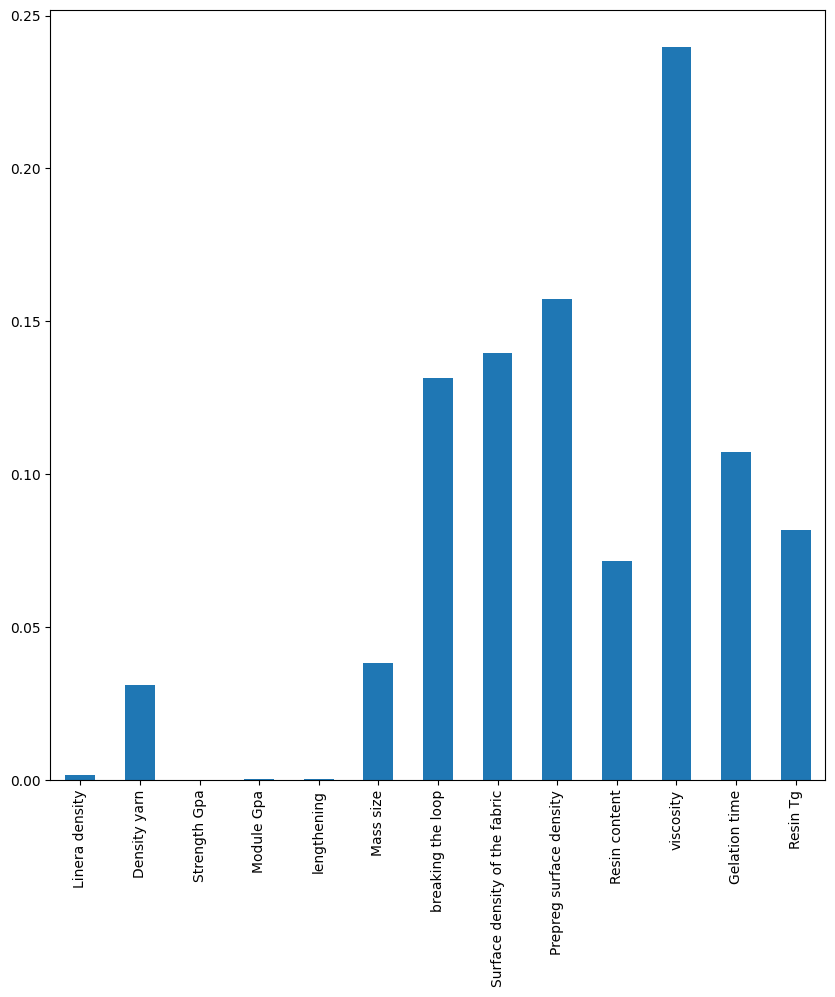

In [20]:
plt.rcParams['figure.figsize'] = (10,10)

feat_imp = pd.Series(model_rf_density.feature_importances_, X.columns)

feat_imp.plot(kind='bar')

In [21]:
print('Линейная регрессия. Плотность:', np.average(model_lr_density.predict(X)))
print('Случайный лес регрессия. Плотность:', np.average(model_rf_density.predict(X)))

Линейная регрессия. Плотность: 1.5388442477012194
Случайный лес регрессия. Плотность: 1.5388382913991907


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.0s finished


### Модель для предсказания прочности углепластика Strength

In [22]:
train_data_strength = df.drop(['Thickness_monolayer', 'Module_plastik',
       'LSS', 'Plastik_Tg', 'density'], axis=1)

X = train_data_strength.drop(['Strength_plastik'], axis=1)
y = train_data_strength.Strength_plastik.values

In [23]:
# воспользуемся специальной функцие train_test_split для разделения тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED)

In [24]:
# НАСТРОЙКИ 
model_rf_strength = RandomForestRegressor(
    n_estimators=600,
    max_features=4,
    min_samples_leaf=5,
    max_depth=9,
    verbose=1, 
    n_jobs=-1, 
    random_state=RANDOM_SEED)

# обучаем модель на тестовом наборе данных
model_rf_strength.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_rf_strength.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 600 out of 600 | elapsed:    0.4s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 600 out of 600 | elapsed:    0.0s finished


In [25]:
print('model_rf_strength MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_rf_strength MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_rf_strength MSE: 12.067
model_rf_strength MAPE: 0.036


In [26]:
model_lr_strength = LinearRegression()

# обучаем модель на тестовом наборе данных
model_lr_strength.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_lr_strength.predict(X_test)

print('model_lr_strength MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_lr_strength MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_lr_strength MSE: 479.289
model_lr_strength MAPE: 1.833


In [27]:
model_xgb_strenght = XGBRegressor(lerning_rate = 0.01)

# обучаем модель на тестовом наборе данных
model_xgb_strenght.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_xgb_strenght.predict(X_test)

print('model_xgb_strenghtMSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_xgb_strenght MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

/home/alexandr/anaconda3/envs/ptn312/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:25:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "lerning_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


model_xgb_strenghtMSE: 21.984
model_xgb_strenght MAPE: 0.032


<Axes: >

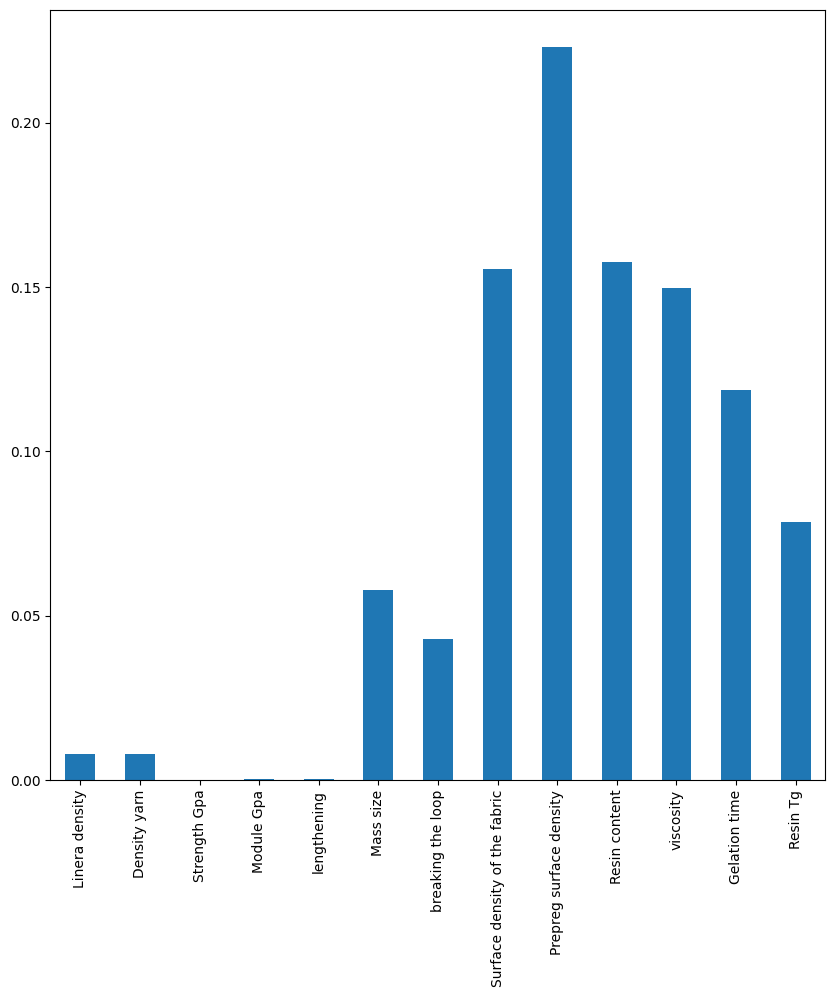

In [28]:
plt.rcParams['figure.figsize'] = (10,10)

feat_imp = pd.Series(model_rf_strength.feature_importances_, X.columns)

feat_imp.plot(kind='bar')

In [29]:
print('Линейная регрессия. Прочность:', np.average(model_lr_strength.predict(X)))
print('Случайный лес регрессия. Прочность:', np.average(model_rf_strength.predict(X)))
print('XGB регрессия. Прочность:', np.average(model_xgb_strenght.predict(X)))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 600 out of 600 | elapsed:    0.0s finished


Линейная регрессия. Прочность: 931.27323478388
Случайный лес регрессия. Прочность: 931.1489138127049
XGB регрессия. Прочность: 931.16077


### Модель для предсказания модуля углепластика Module

In [30]:
train_data_module = df.drop(['Thickness_monolayer', 'density', 'Strength_plastik',
       'LSS', 'Plastik_Tg'], axis=1)

X = train_data_module.drop(['Module_plastik'], axis=1)
y = train_data_module.Module_plastik .values

In [31]:
# воспользуемся специальной функцие train_test_split для разделения тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED)

# НАСТРОЙКИ 
model_rf_module = RandomForestRegressor(
    n_estimators=500, 
    max_features=4,
    min_samples_leaf=5,
    max_depth=9,
    verbose=1, 
    n_jobs=-1, 
    random_state=RANDOM_SEED)

# обучаем модель на тестовом наборе данных
model_rf_module.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_rf_module.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.0s finished


In [32]:
print('model_rf_module MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_rf_module MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_rf_module MSE: 0.022
model_rf_module MAPE: 0.028


In [33]:
model_lr_module = LinearRegression()

# обучаем модель на тестовом наборе данных
model_lr_module.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_lr_module.predict(X_test)

print('model_lr_module MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_lr_moduleMAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_lr_module MSE: 2.988
model_lr_moduleMAPE: 2.183


<Axes: >

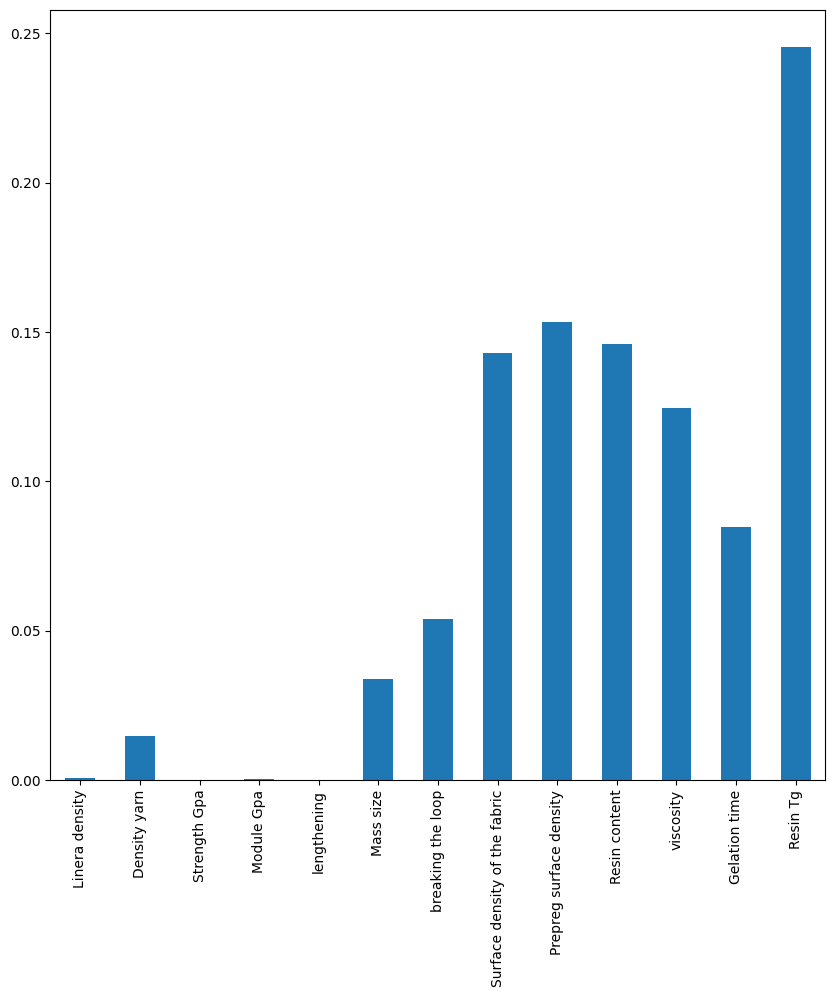

In [34]:
plt.rcParams['figure.figsize'] = (10,10)

feat_imp = pd.Series(model_rf_module.feature_importances_, X.columns)

feat_imp.plot(kind='bar')

In [35]:
print('Линейная регрессия. Модуль упругости:', np.average(model_lr_module.predict(X)))
print('Случайный лес регрессия. Модуль упругости:', np.average(model_rf_module.predict(X)))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.


Линейная регрессия. Модуль упругости: 68.01790483787943
Случайный лес регрессия. Модуль упругости: 68.01402211469355


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.0s finished


### Модель для предсказания межслоевой прочности углепластика LSS

In [36]:
train_data_lss = df.drop(['Thickness_monolayer', 'density', 'Strength_plastik', 'Module_plastik',
                             'Plastik_Tg'], axis=1)

X = train_data_lss.drop(['LSS'], axis=1)
y = train_data_lss.LSS.values

In [37]:
# воспользуемся специальной функцие train_test_split для разделения тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED)

# НАСТРОЙКИ 
model_rf_lss = RandomForestRegressor(
    n_estimators=500,
    max_features=4,
    min_samples_leaf=5,
    max_depth=9,
    verbose=1, 
    n_jobs=-1, 
    random_state=RANDOM_SEED)

# обучаем модель на тестовом наборе данных
model_rf_lss.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_rf_lss.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.4s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.0s finished


In [38]:
print('model_rf_lss MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_rf_lss MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_rf_lss MSE: 0.12
model_rf_lss MAPE: 0.061


In [39]:
model_lr_lss = LinearRegression()

# обучаем модель на тестовом наборе данных
model_lr_lss.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_lr_lss.predict(X_test)

print('model_lr_lss MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_lr_lssMAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_lr_lss MSE: 16.151
model_lr_lssMAPE: 4.074


In [40]:
model_xgb_lss = XGBRegressor(lerning_rate = 0.01)

# обучаем модель на тестовом наборе данных
model_xgb_lss.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_xgb_lss.predict(X_test)

print('model_xgb_lss MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_xgb_lss MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

/home/alexandr/anaconda3/envs/ptn312/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:25:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "lerning_rate" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


model_xgb_lss MSE: 0.155
model_xgb_lss MAPE: 0.026


<Axes: >

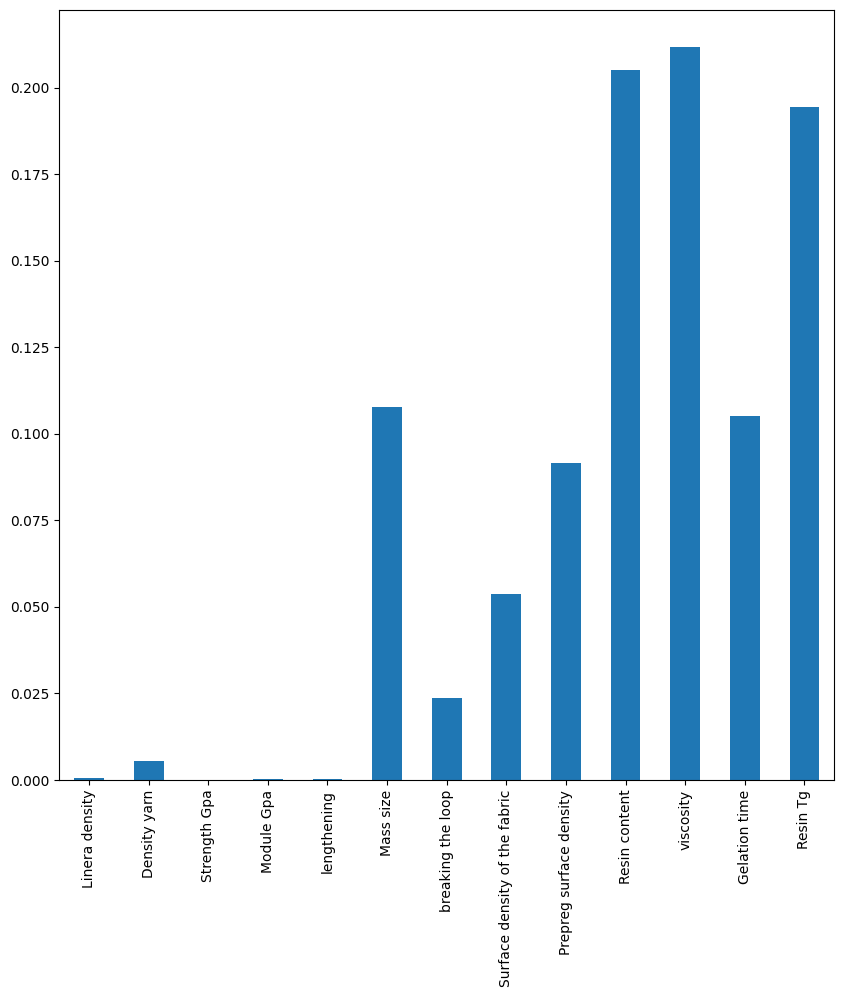

In [41]:
plt.rcParams['figure.figsize'] = (10,10)

feat_imp = pd.Series(model_rf_lss.feature_importances_, X.columns)

feat_imp.plot(kind='bar')

In [42]:
print('Линейная регрессия. Прочность при сдвиге:', np.average(model_lr_lss.predict(X)))
print('Случайный лес регрессия. Прочность при сдвиге:', np.average(model_rf_lss.predict(X)))
print('XGB регрессия. Прочность при сдвиге:', np.average(model_xgb_lss.predict(X)))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.0s finished


Линейная регрессия. Прочность при сдвиге: 78.64150355251704
Случайный лес регрессия. Прочность при сдвиге: 78.65884760661699
XGB регрессия. Прочность при сдвиге: 78.66261


# Модель для предсказания температуры стеклования углепластика Tg

In [43]:
train_data_Tg = df.drop(['Thickness_monolayer', 'density', 'Strength_plastik', 'Module_plastik', 
                         'LSS'], axis=1)

X = train_data_Tg.drop(['Plastik_Tg'], axis=1)
y = train_data_Tg.Plastik_Tg.values

In [44]:
# воспользуемся специальной функцие train_test_split для разделения тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED)

# НАСТРОЙКИ 
model_rf_Tg = RandomForestRegressor(
    n_estimators=500,
    max_features=4,
    min_samples_leaf=5,
    max_depth=9,
    verbose=1, 
    n_jobs=-1, 
    random_state=RANDOM_SEED)

# обучаем модель на тестовом наборе данных
model_rf_Tg.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_rf_Tg.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.4s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.1s finished


In [45]:
print('model_rf_Tg MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_rf_Tg MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_rf_Tg MSE: 0.029
model_rf_Tg MAPE: 0.012


In [46]:
model_lr_Tg = LinearRegression()

# обучаем модель на тестовом наборе данных
model_lr_Tg.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_lr_Tg.predict(X_test)

print('model_lr_Tg MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('model_lr_Tg MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

model_lr_Tg MSE: 3.486
model_lr_Tg MAPE: 0.93


<Axes: >

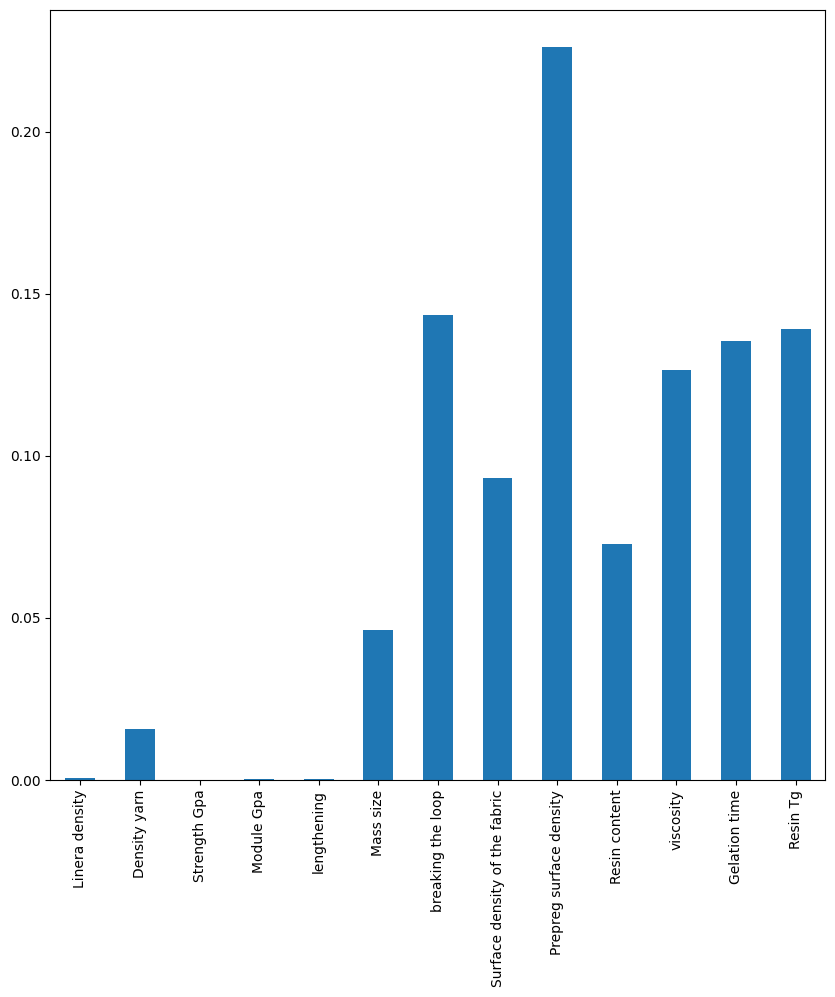

In [47]:
plt.rcParams['figure.figsize'] = (10,10)

feat_imp = pd.Series(model_rf_Tg.feature_importances_, X.columns)

feat_imp.plot(kind='bar')

In [48]:
print('Линейная регрессия. Температура стеклования:', np.average(model_lr_Tg.predict(X)))
print('Случайный лес регрессия. Температура стеклования:', np.average(model_rf_Tg.predict(X)))

Линейная регрессия. Температура стеклования: 160.00059445500239
Случайный лес регрессия. Температура стеклования: 160.00864147156676


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 500 out of 500 | elapsed:    0.0s finished
